# Superficie de sintonización del controlador PID: $K_P$, $K_D$ y $\rho$ según el RMSE

En la presente libreta se representan gráficamente, en forma de superficie, las constantes de sintonización obtenidas mediante el algoritmo genético para la población de pacientes contenida en el archivo `SINTONIZACIONES.csv`. La superficie se define sobre el plano $(K_P, K_D)$; su altura corresponde al valor de $\rho$ y su color codifica la raíz del error cuadrático medio (RMSE) alcanzada en lazo cerrado.

**Construcción de la superficie.** Dado que las sintonizaciones constituyen un conjunto de puntos dispersos, y que para un mismo par $(K_P, K_D)$ no existe un único valor de $\rho$, la superficie se obtiene mediante regresión por núcleo gaussiano (estimador de Nadaraya–Watson) sobre una malla regular. En cada nodo de la malla se calcula un promedio ponderado de $\rho$ y del RMSE de los pacientes, en el que el peso de cada paciente decrece con su distancia al nodo. En consecuencia, la superficie representa la **tendencia local** de ambas magnitudes y no los valores individuales de cada paciente.

**Nota de notación.** La columna `gamma` del archivo corresponde al parámetro de escalamiento del remifentanilo de la Arquitectura I, el cual se denota $\rho$ en la tesis (el símbolo $\gamma$ queda reservado para la pendiente de Hill). Las ganancias se denotan $K_P$ y $K_D$ conforme a la convención de notación adoptada. La ganancia integral $K_I$ no se incluye en la superficie tridimensional, dado que sus valores se concentran en un intervalo muy próximo a cero; no obstante, se incorpora en la figura de proyecciones por pares de la Sección 6, donde se representa en escala logarítmica.

## 1. Importación de bibliotecas y configuración del estilo gráfico

In [1]:
# Se importan las bibliotecas necesarias para la lectura de datos, el suavizado y la generación de figuras.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LightSource, LinearSegmentedColormap, Normalize

# Se define la paleta de colores vívidos empleada de manera uniforme en las figuras de la tesis.
AZUL_MARINO = "#0B1F5C"
ROSA_FLUOR = "#FF1493"
ROJO = "#E0001B"
AMARILLO = "#FFD000"
ESMERALDA = "#00A86B"

# Se establecen los parámetros globales de estilo: tipografía, grosor de marcos y tamaño de etiquetas.
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.labelsize": 15,
    "axes.titlesize": 16,
    "axes.linewidth": 3.0,
    "axes.edgecolor": AZUL_MARINO,
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "figure.dpi": 110,
    "savefig.dpi": 300,
})

# Se construye un mapa de color secuencial para el RMSE: los tonos azules representan
# el error mínimo, los tonos verdes un error intermedio y los tonos rojos el error de
# mayor magnitud. Entre el verde y el rojo se intercalan el amarillo y el naranja, con
# el fin de evitar los tonos pardos que resultarían de una interpolación directa.
MAPA_RMSE = LinearSegmentedColormap.from_list(
    "rmse_azul_verde_rojo",
    [AZUL_MARINO, "#1E64FF", "#00B4D8", ESMERALDA, "#7ED957", AMARILLO, "#FF7A00", ROJO],
    N=256,
)

# Se definen los colores de la estrella que señala el mínimo de la superficie.
BLANCO = "#FFFFFF"

## 2. Lectura y descripción de los datos de sintonización

In [2]:
# Se especifica la ruta del archivo de sintonizaciones. 
RUTA_CSV = Path("SINTONIZACIONES.csv")

# Se leen los datos y se renombra la columna "gamma" como "rho"
datos = pd.read_csv(RUTA_CSV).rename(columns={"gamma": "rho"})

# Se verifica la ausencia de valores faltantes en las columnas de interés.
columnas = ["Kp", "Kd", "rho", "RMSE"]
assert datos[columnas].notna().all().all(), "Se detectaron valores faltantes en las columnas de interés."

print(f"Número de pacientes: {len(datos)}")
print(datos["Sexo"].value_counts().rename("Pacientes por sexo").to_string(), "\n")

# Se presenta el resumen estadístico de las constantes y del error.
datos[["Kp", "Ki", "Kd", "rho", "RMSE"]].describe().round(4)

Número de pacientes: 340
Sexo
M    170
F    170 



,Kp,Ki,Kd,rho,RMSE
count,340.0000,340.0,340.0000,340.0000,340.0000
mean,0.0048,0.0,0.4243,1.4419,5.5978
std,0.0028,0.0,0.1205,0.6470,0.2561
min,0.0017,0.0,0.0000,0.2752,5.0274
25%,0.0032,0.0,0.3593,0.9433,5.4289
50%,0.0043,0.0,0.5000,1.3715,5.5798
75%,0.0056,0.0,0.5000,1.8882,5.7459
max,0.0313,0.0,0.5000,3.0000,6.6048


## 3. Construcción de la superficie mediante regresión por núcleo gaussiano

Las variables del plano se normalizan al intervalo $[0, 1]$ para que el ancho de banda $h$ tenga el mismo significado en ambas direcciones. Para cada nodo $\mathbf{g}$ de la malla, la estimación de una magnitud $y$ (ya sea $\rho$ o el RMSE) se calcula como

$$\hat{y}(\mathbf{g}) = \frac{\sum_{i=1}^{N} \omega_i(\mathbf{g})\, y_i}{\sum_{i=1}^{N} \omega_i(\mathbf{g})}, \qquad \omega_i(\mathbf{g}) = \exp\!\left(-\frac{\lVert \mathbf{g} - \mathbf{z}_i \rVert^2}{2h^2}\right),$$

donde $\mathbf{z}_i$ es el par $(K_P, K_D)$ normalizado del paciente $i$. Un valor mayor de $h$ produce una superficie más suave; un valor menor conserva más detalle local, a costa de mayor irregularidad. Adicionalmente, se calcula el número efectivo de pacientes que sustentan cada nodo, $N_{\mathrm{ef}} = \left(\sum_i \omega_i\right)^2 / \sum_i \omega_i^2$, y se omiten los nodos con escaso soporte en los datos.

**Escala de $K_P$.** Los valores de $K_P$ abarcan aproximadamente un orden de magnitud y se concentran en el extremo inferior de su intervalo, con unos cuantos pacientes de valor elevado; además, el algoritmo genético explora esta ganancia en escala logarítmica. Por ello, la coordenada $K_P$ del plano se suaviza y se representa en escala logarítmica ($\log_{10} K_P$). De este modo los pacientes se distribuyen de manera más uniforme sobre la malla y se evita que unos pocos valores elevados de $K_P$ dejen sin soporte una porción considerable del plano, lo que produciría una superficie recortada.


In [3]:
# Se definen los parámetros del suavizado: resolución de la malla, ancho de banda del
# núcleo (en unidades normalizadas) y número efectivo mínimo de pacientes por nodo.
RESOLUCION = 80
# El ancho de banda se elige como el menor valor con el que todos los nodos de la
# malla conservan un número efectivo de pacientes de al menos N_EF_MINIMO, de modo
# que la superficie cubre el plano completo sin extrapolar fuera de los datos.
ANCHO_BANDA = 0.16
N_EF_MINIMO = 3.0
KP_LOGARITMICA = True    # Suavizado y representación de K_P en escala logarítmica

# Se extraen las coordenadas del plano (K_P, K_D) y las magnitudes a estimar.
plano = datos[["Kp", "Kd"]].to_numpy()
rho_obs = datos["rho"].to_numpy()
rmse_obs = datos["RMSE"].to_numpy()

# Se obtienen las coordenadas de suavizado: log10(K_P) cuando se emplea la escala
# logarítmica y K_D en escala lineal. Se normalizan al intervalo [0, 1].
plano_suav = plano.copy()
if KP_LOGARITMICA:
    plano_suav[:, 0] = np.log10(plano[:, 0])
minimos, maximos = plano_suav.min(axis=0), plano_suav.max(axis=0)
plano_norm = (plano_suav - minimos) / (maximos - minimos)

# Se construye la malla regular en unidades normalizadas y en unidades originales.
eje_norm = np.linspace(0.0, 1.0, RESOLUCION)
malla_u, malla_v = np.meshgrid(eje_norm, eje_norm)
nodos = np.column_stack([malla_u.ravel(), malla_v.ravel()])
# KP_SUAV contiene la coordenada de suavizado (log10 K_P o K_P); KP, las unidades originales.
KP_SUAV = minimos[0] + malla_u * (maximos[0] - minimos[0])
KP = 10.0 ** KP_SUAV if KP_LOGARITMICA else KP_SUAV
KD = minimos[1] + malla_v * (maximos[1] - minimos[1])

# Se calculan los pesos gaussianos de cada paciente con respecto a cada nodo de la malla.
distancias_cuad = ((nodos[:, None, :] - plano_norm[None, :, :]) ** 2).sum(axis=-1)
pesos = np.exp(-distancias_cuad / (2.0 * ANCHO_BANDA ** 2))
suma_pesos = pesos.sum(axis=1)

# Se obtienen las estimaciones de Nadaraya-Watson para rho y para el RMSE.
RHO = ((pesos @ rho_obs) / suma_pesos).reshape(KP.shape)
RMSE_EST = ((pesos @ rmse_obs) / suma_pesos).reshape(KP.shape)

# Se calcula el número efectivo de pacientes por nodo y se omiten los nodos con escaso soporte.
N_EF = (suma_pesos ** 2 / (pesos ** 2).sum(axis=1)).reshape(KP.shape)
sin_soporte = N_EF < N_EF_MINIMO
RHO = np.where(sin_soporte, np.nan, RHO)
RMSE_EST = np.where(sin_soporte, np.nan, RMSE_EST)

print(f"Nodos omitidos por escaso soporte: {int(sin_soporte.sum())} de {sin_soporte.size}")
print(f"Intervalo de rho estimado:  [{np.nanmin(RHO):.3f}, {np.nanmax(RHO):.3f}]")
print(f"Intervalo de RMSE estimado: [{np.nanmin(RMSE_EST):.3f}, {np.nanmax(RMSE_EST):.3f}]")

Nodos omitidos por escaso soporte: 0 de 6400
Intervalo de rho estimado:  [0.827, 1.683]
Intervalo de RMSE estimado: [5.407, 6.216]


## 4. Superficie tridimensional $(K_P, K_D, \rho)$ con escala según el RMSE



Mínimo de la superficie: K_P = 0.001706, K_D = 0.500, rho = 1.683, RMSE estimado = 5.407


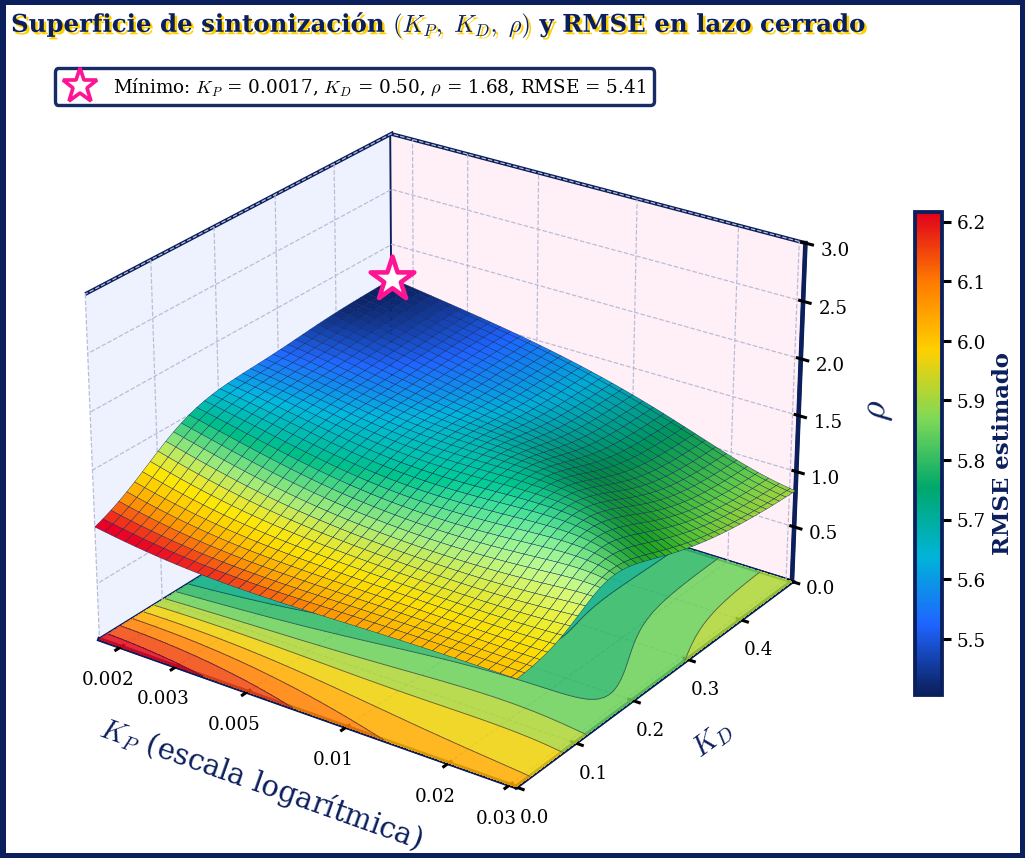

In [4]:
# Se localiza el nodo de la malla con el menor RMSE estimado (mínimo de la superficie).
fila_min, col_min = np.unravel_index(np.nanargmin(RMSE_EST), RMSE_EST.shape)
kp_min, kd_min = KP[fila_min, col_min], KD[fila_min, col_min]
kp_min_suav = KP_SUAV[fila_min, col_min]
rho_min, rmse_min = RHO[fila_min, col_min], RMSE_EST[fila_min, col_min]
print(f"Mínimo de la superficie: K_P = {kp_min:.4g}, K_D = {kd_min:.3f}, "
      f"rho = {rho_min:.3f}, RMSE estimado = {rmse_min:.3f}")

# Se normaliza la escala de color con respecto al intervalo del RMSE estimado.
normalizacion = Normalize(vmin=np.nanmin(RMSE_EST), vmax=np.nanmax(RMSE_EST))

# Se asignan los colores de la superficie según el RMSE estimado y se aplica un sombreado
# por iluminación direccional, el cual confiere el efecto de relieve.
colores = MAPA_RMSE(normalizacion(np.nan_to_num(RMSE_EST, nan=np.nanmean(RMSE_EST))))
iluminacion = LightSource(azdeg=315, altdeg=40)
colores_sombreados = iluminacion.shade_rgb(
    colores[..., :3], np.nan_to_num(RHO, nan=np.nanmean(RHO)),
    vert_exag=2.0, blend_mode="soft",
)
colores_sombreados = np.dstack([colores_sombreados, np.where(sin_soporte, 0.0, 1.0)])

# Se fijan los límites verticales al intervalo completo de rho observado en los pacientes,
# de modo que la escala del eje no exagere las variaciones de la superficie.
z_min, z_max = 0.0, float(np.ceil(rho_obs.max()))

fig = plt.figure(figsize=(12, 9.5))
# Se desactiva el ordenamiento automático de profundidad, de modo que los elementos se
# superpongan según su orden de dibujo y la estrella permanezca visible sobre la superficie.
ax = fig.add_subplot(111, projection="3d", computed_zorder=False)

# Se proyecta sobre el plano inferior el mapa de contornos del RMSE estimado.
ax.contourf(KP_SUAV, KD, RMSE_EST, levels=14, zdir="z", offset=z_min,
            cmap=MAPA_RMSE, norm=normalizacion, alpha=0.85, zorder=1)
ax.contour(KP_SUAV, KD, RMSE_EST, levels=14, zdir="z", offset=z_min,
           colors=AZUL_MARINO, linewidths=0.6, alpha=0.6, zorder=2)

# Se dibuja la superficie con una retícula fina en azul marino que resalta su curvatura.
ax.plot_surface(
    KP_SUAV, KD, RHO,
    facecolors=colores_sombreados,
    rstride=2, cstride=2,
    edgecolor=AZUL_MARINO, linewidth=0.25,
    antialiased=True, shade=False, zorder=3,
)

# Se señala el mínimo de la superficie mediante una estrella blanca con delineado rosa.
ax.scatter(kp_min_suav, kd_min, rho_min, marker="*", s=900, color=BLANCO,
           edgecolors=ROSA_FLUOR, linewidths=3.0, depthshade=False, zorder=6)

# Se configuran los límites y las etiquetas de los ejes.
ax.set_xlim(minimos[0], maximos[0])
ax.set_ylim(minimos[1], maximos[1])
# En escala logarítmica, las marcas del eje K_P se rotulan en unidades originales.
if KP_LOGARITMICA:
    marcas_kp = [v for v in (0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1)
                 if minimos[0] <= np.log10(v) <= maximos[0]]
    ax.set_xticks(np.log10(marcas_kp))
    ax.set_xticklabels([f"{v:g}" for v in marcas_kp])
ax.set_zlim(z_min, z_max)
ax.set_xlabel(r"$K_P$ (escala logarítmica)" if KP_LOGARITMICA else r"$K_P$", labelpad=14, color=AZUL_MARINO, fontsize=19)
ax.set_ylabel(r"$K_D$", labelpad=12, color=AZUL_MARINO, fontsize=19)
ax.set_zlabel(r"$\rho$", labelpad=10, color=AZUL_MARINO, fontsize=25)

# Se colorean las paredes del volumen con tonos claros y se engrosan sus aristas.
for eje, tono in zip((ax.xaxis, ax.yaxis, ax.zaxis), ("#EEF2FF", "#FFF0F7", "#FFFBE6")):
    eje.set_pane_color(tono)
    eje.pane.set_edgecolor(AZUL_MARINO)
    eje.pane.set_linewidth(2.5)
    eje.line.set_color(AZUL_MARINO)
    eje.line.set_linewidth(3.0)
    eje._axinfo["grid"].update(color="#B8BCD6", linewidth=0.8, linestyle="--")

# Se fija el ángulo de observación que ofrece la mejor lectura de la superficie.
ax.view_init(elev=26, azim=-55)

# Se agrega la barra de color correspondiente al RMSE estimado, con marco grueso.
mapeador = ScalarMappable(norm=normalizacion, cmap=MAPA_RMSE)
barra = fig.colorbar(mapeador, ax=ax, shrink=0.6, pad=0.08, aspect=18)
barra.set_label("RMSE estimado", fontsize=15, color=AZUL_MARINO, fontweight="bold")
barra.outline.set_linewidth(2.5)
barra.outline.set_edgecolor(AZUL_MARINO)

# Se agrega la leyenda que identifica el mínimo de la superficie.
from matplotlib.lines import Line2D
marcador_minimo = Line2D([0], [0], marker="*", linestyle="none", markersize=24,
                         markerfacecolor=BLANCO, markeredgecolor=ROSA_FLUOR, markeredgewidth=2.4,
                         label=(rf"Mínimo: $K_P$ = {kp_min:.4f}, $K_D$ = {kd_min:.2f}, "
                                rf"$\rho$ = {rho_min:.2f}, RMSE = {rmse_min:.2f}"))
marco_leyenda = ax.legend(handles=[marcador_minimo], loc="upper left", fontsize=12,
                          frameon=True, edgecolor=AZUL_MARINO, framealpha=0.95).get_frame()
marco_leyenda.set_linewidth(2.2)

# Se añade el título con una sombra desplazada que le confiere relieve.
ax.set_title(r"Superficie de sintonización $(K_P,\ K_D,\ \rho)$ y RMSE en lazo cerrado",
             pad=18, color=AZUL_MARINO, fontweight="bold",
             path_effects=[pe.withSimplePatchShadow(offset=(1.6, -1.6), shadow_rgbFace=AMARILLO, alpha=1.0)])

# Se dibuja un marco grueso alrededor de la figura completa.
fig.patch.set_edgecolor(AZUL_MARINO)
fig.patch.set_linewidth(6)

plt.show()
figura_3d = fig

## 5. Mapas bidimensionales de $\rho$ y del RMSE sobre el plano $(K_P, K_D)$

Como complemento de la vista tridimensional,  se presentan dos mapas de contornos rellenos sobre el plano $(K_P, K_D)$: el primero muestra la altura de la superficie ($\rho$ estimado) y el segundo su color (RMSE estimado).

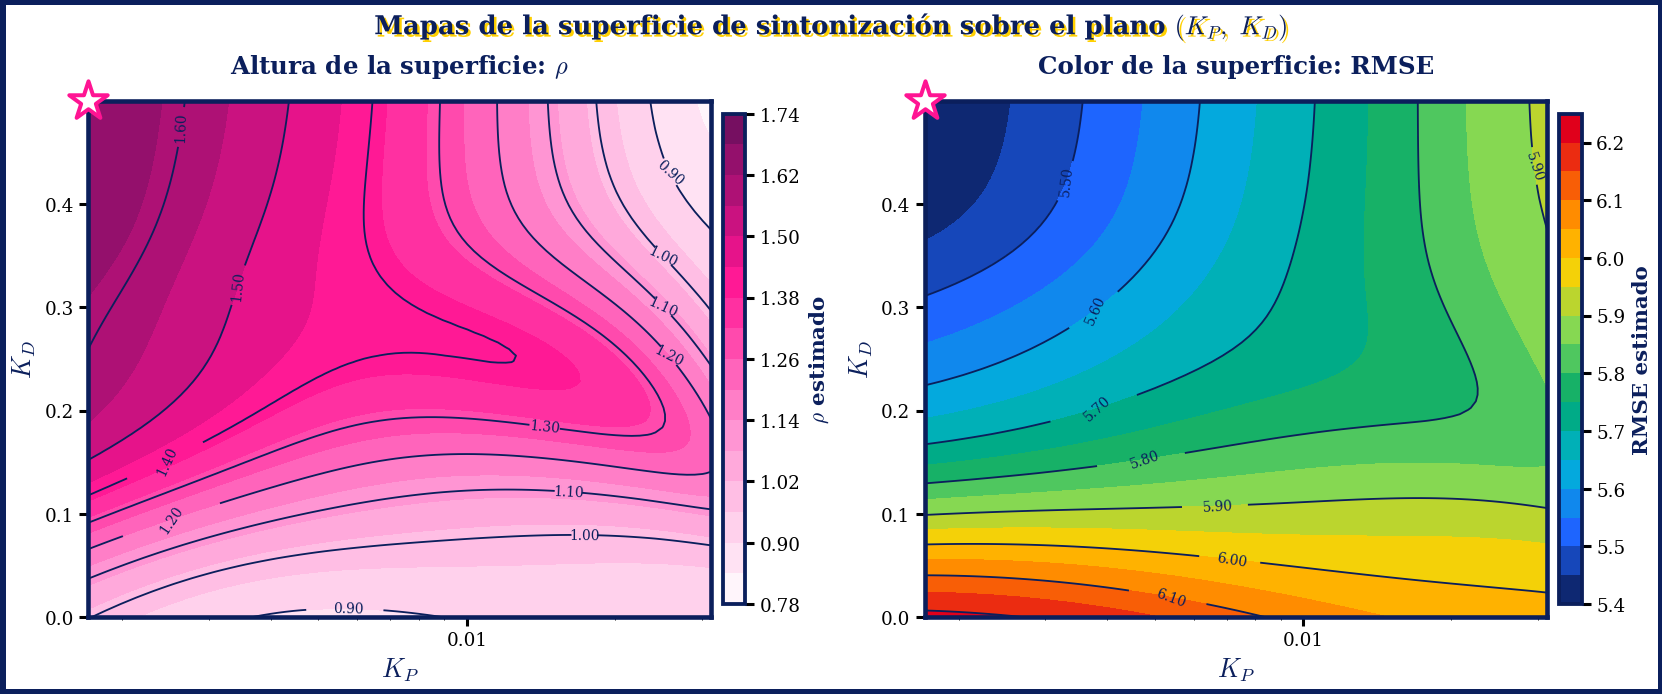

In [5]:
# Se construye un mapa de color secuencial para rho en tonos rosas y violetas, con el fin
# de que no se confunda con la escala azul-verde-rojo reservada para el RMSE.
MAPA_RHO = LinearSegmentedColormap.from_list("rho_vivido", ["#FFFFFF", "#FF9AD5", ROSA_FLUOR, "#6A0F5C"], N=256)

from matplotlib.ticker import FuncFormatter

fig2, ejes = plt.subplots(1, 2, figsize=(15, 6.2), constrained_layout=True)

paneles = [
    (RHO, MAPA_RHO, None, r"$\rho$ estimado", r"Altura de la superficie: $\rho$"),
    (RMSE_EST, MAPA_RMSE, normalizacion, "RMSE estimado", "Color de la superficie: RMSE"),
]

for ax2, (campo, mapa, norma, etiqueta_barra, titulo) in zip(ejes, paneles):
    # Se dibujan los contornos rellenos y las isolíneas correspondientes.
    relleno = ax2.contourf(KP, KD, campo, levels=16, cmap=mapa, norm=norma)
    isolineas = ax2.contour(KP, KD, campo, levels=8, colors=AZUL_MARINO, linewidths=1.2)
    ax2.clabel(isolineas, fmt="%.2f", fontsize=9, inline=True)

    # Se señala el mínimo de la superficie mediante una estrella blanca con delineado rosa.
    ax2.scatter(kp_min, kd_min, marker="*", s=700, color=BLANCO,
                edgecolors=ROSA_FLUOR, linewidths=2.6, zorder=5, clip_on=False)

    # Escala logarítmica del eje K_P, con marcas rotuladas en unidades originales
    if KP_LOGARITMICA:
        ax2.set_xscale("log")
        ax2.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
        ax2.xaxis.set_minor_formatter(FuncFormatter(lambda v, _: ""))

    ax2.set_xlabel(r"$K_P$", color=AZUL_MARINO, fontsize=17)
    ax2.set_ylabel(r"$K_D$", color=AZUL_MARINO, fontsize=17)
    ax2.set_title(titulo, color=AZUL_MARINO, fontweight="bold", pad=18)

    # Se engrosan los marcos de cada panel.
    for borde in ax2.spines.values():
        borde.set_linewidth(3.0)
        borde.set_edgecolor(AZUL_MARINO)

    # Se agrega una barra de color independiente para cada panel.
    barra2 = fig2.colorbar(relleno, ax=ax2, shrink=0.95, aspect=22, pad=0.02)
    barra2.set_label(etiqueta_barra, fontsize=14, color=AZUL_MARINO, fontweight="bold")
    barra2.outline.set_linewidth(2.5)
    barra2.outline.set_edgecolor(AZUL_MARINO)

fig2.suptitle(r"Mapas de la superficie de sintonización sobre el plano $(K_P,\ K_D)$",
              fontsize=17, color=AZUL_MARINO, fontweight="bold",
              path_effects=[pe.withSimplePatchShadow(offset=(1.6, -1.6), shadow_rgbFace=AMARILLO, alpha=1.0)])
fig2.patch.set_edgecolor(AZUL_MARINO)
fig2.patch.set_linewidth(6)

plt.show()

## 6. Proyecciones de la superficie para cada par de constantes del controlador

En esta figura se consideran las cuatro constantes del controlador ($K_P$, $K_I$, $K_D$ y $\rho$) y se construye un panel para cada uno de los seis pares posibles. En cada panel se estima el RMSE sobre el plano del par correspondiente mediante el mismo estimador de Nadaraya–Watson y el mismo ancho de banda empleados en la Sección 3, de modo que cada panel constituye la proyección bidimensional de la superficie de error sobre dicho plano. La estrella blanca con delineado rosa señala, en cada panel, el nodo con el menor RMSE estimado. Todos los paneles comparten la misma escala de color, lo que permite comparar directamente los niveles de error entre ellos.

**Tratamiento de $K_I$ y $K_P$.** Los valores de $K_I$ abarcan varios órdenes de magnitud, por lo que su eje se representa en escala logarítmica y el suavizado se realiza sobre $\log_{10} K_I$; por la razón expuesta en la Sección 3, el eje de $K_P$ también se representa en escala logarítmica. Los pacientes cuyo valor de $K_I$ coincide con el límite inferior del espacio de búsqueda del algoritmo genético ($10^{-9}$, equivalente a una acción integral nula) se representan en un valor mínimo convencional, igual a la potencia de diez inmediatamente inferior al menor valor de $K_I$ observado fuera de dicho límite, con el fin de conservarlos en el análisis sin extender artificialmente el eje. Las zonas sin color corresponden a regiones del plano con escaso soporte en los datos.

In [6]:
from itertools import combinations

# Se define el valor mínimo convencional con el que se representan los pacientes cuyo
# K_I coincide con el límite inferior del espacio de búsqueda (acción integral nula):
# la potencia de diez inmediatamente inferior al menor K_I observado fuera de dicho
# límite. El límite inferior coincide con GANANCIAS_INF de PID_Filtro_EMA.ipynb.
LIM_INF_KI = 1e-9
en_limite_ki = datos["Ki"] <= 10 * LIM_INF_KI
ki_validos = datos.loc[~en_limite_ki, "Ki"]
PISO_KI = 10.0 ** np.floor(np.log10(ki_validos.min())) if len(ki_validos) else LIM_INF_KI
datos["Ki_graf"] = datos["Ki"].where(~en_limite_ki, PISO_KI)
print(f"Pacientes con K_I en el límite inferior (representados en {PISO_KI:.0e}): "
      f"{int(en_limite_ki.sum())}")

# Se describen las cuatro constantes del controlador: columna de datos, etiqueta y escala del eje.
VARIABLES = {
    "Kp":  dict(columna="Kp",      etiqueta=r"$K_P$",  logaritmica=KP_LOGARITMICA),
    "Ki":  dict(columna="Ki_graf", etiqueta=r"$K_I$",  logaritmica=True),
    "Kd":  dict(columna="Kd",      etiqueta=r"$K_D$",  logaritmica=False),
    "rho": dict(columna="rho",     etiqueta=r"$\rho$", logaritmica=False),
}


def proyectar_superficie(var_x, var_y, resolucion=RESOLUCION, ancho_banda=ANCHO_BANDA,
                         n_ef_minimo=N_EF_MINIMO):
    """Estima el RMSE sobre una malla regular del plano (var_x, var_y) mediante el estimador
    de Nadaraya-Watson con núcleo gaussiano. Las variables con escala logarítmica se
    suavizan sobre su logaritmo decimal. Devuelve las mallas de coordenadas, en unidades
    originales, y la malla del RMSE estimado, con valores faltantes en los nodos de escaso soporte."""
    # Se obtienen las coordenadas de los pacientes en el espacio de suavizado.
    coordenadas = []
    for var in (var_x, var_y):
        valores = datos[VARIABLES[var]["columna"]].to_numpy(dtype=float)
        coordenadas.append(np.log10(valores) if VARIABLES[var]["logaritmica"] else valores)
    coordenadas = np.column_stack(coordenadas)

    # Se normalizan las coordenadas al intervalo [0, 1] y se construye la malla regular.
    inferior, superior = coordenadas.min(axis=0), coordenadas.max(axis=0)
    coord_norm = (coordenadas - inferior) / (superior - inferior)
    eje = np.linspace(0.0, 1.0, resolucion)
    malla_a, malla_b = np.meshgrid(eje, eje)
    nodos_par = np.column_stack([malla_a.ravel(), malla_b.ravel()])

    # Se calculan los pesos gaussianos, la estimación del RMSE y el número efectivo de pacientes.
    dist_cuad = ((nodos_par[:, None, :] - coord_norm[None, :, :]) ** 2).sum(axis=-1)
    w = np.exp(-dist_cuad / (2.0 * ancho_banda ** 2))
    suma_w = w.sum(axis=1)
    estimacion = (w @ rmse_obs) / suma_w
    n_ef = suma_w ** 2 / (w ** 2).sum(axis=1)
    estimacion = np.where(n_ef < n_ef_minimo, np.nan, estimacion).reshape(malla_a.shape)

    # Se devuelven las coordenadas de la malla en las unidades originales de cada constante.
    X = inferior[0] + malla_a * (superior[0] - inferior[0])
    Y = inferior[1] + malla_b * (superior[1] - inferior[1])
    if VARIABLES[var_x]["logaritmica"]:
        X = 10.0 ** X
    if VARIABLES[var_y]["logaritmica"]:
        Y = 10.0 ** Y
    return X, Y, estimacion


# Se calculan las proyecciones para los seis pares de constantes y se localiza el mínimo de cada una.
pares_controlador = list(combinations(["Kp", "Ki", "Kd", "rho"], 2))
proyecciones, minimos_pares = {}, []
for var_x, var_y in pares_controlador:
    X, Y, E = proyectar_superficie(var_x, var_y)
    i_min, j_min = np.unravel_index(np.nanargmin(E), E.shape)
    proyecciones[(var_x, var_y)] = (X, Y, E, X[i_min, j_min], Y[i_min, j_min], E[i_min, j_min])
    minimos_pares.append({"Par": f"{var_x} - {var_y}", "x mínimo": X[i_min, j_min],
                          "y mínimo": Y[i_min, j_min], "RMSE estimado mínimo": E[i_min, j_min],
                          "Nodos sin soporte": int(np.isnan(E).sum())})

# Se presenta la tabla con la ubicación del mínimo en cada par.
pd.DataFrame(minimos_pares).set_index("Par").round(4)

Pacientes con K_I en el límite inferior (representados en 1e-07): 0


,x mínimo,y mínimo,RMSE estimado mínimo,Nodos sin soporte
Par,,,,
Kp - Ki,0.0017,0.0000,5.4675,272
Kp - Kd,0.0017,0.5000,5.4068,0
Kp - rho,0.0017,2.8275,5.4245,0
Ki - Kd,0.0000,0.5000,5.5209,0
Ki - rho,0.0000,2.6896,5.4387,52
Kd - rho,0.5000,2.6896,5.4673,0


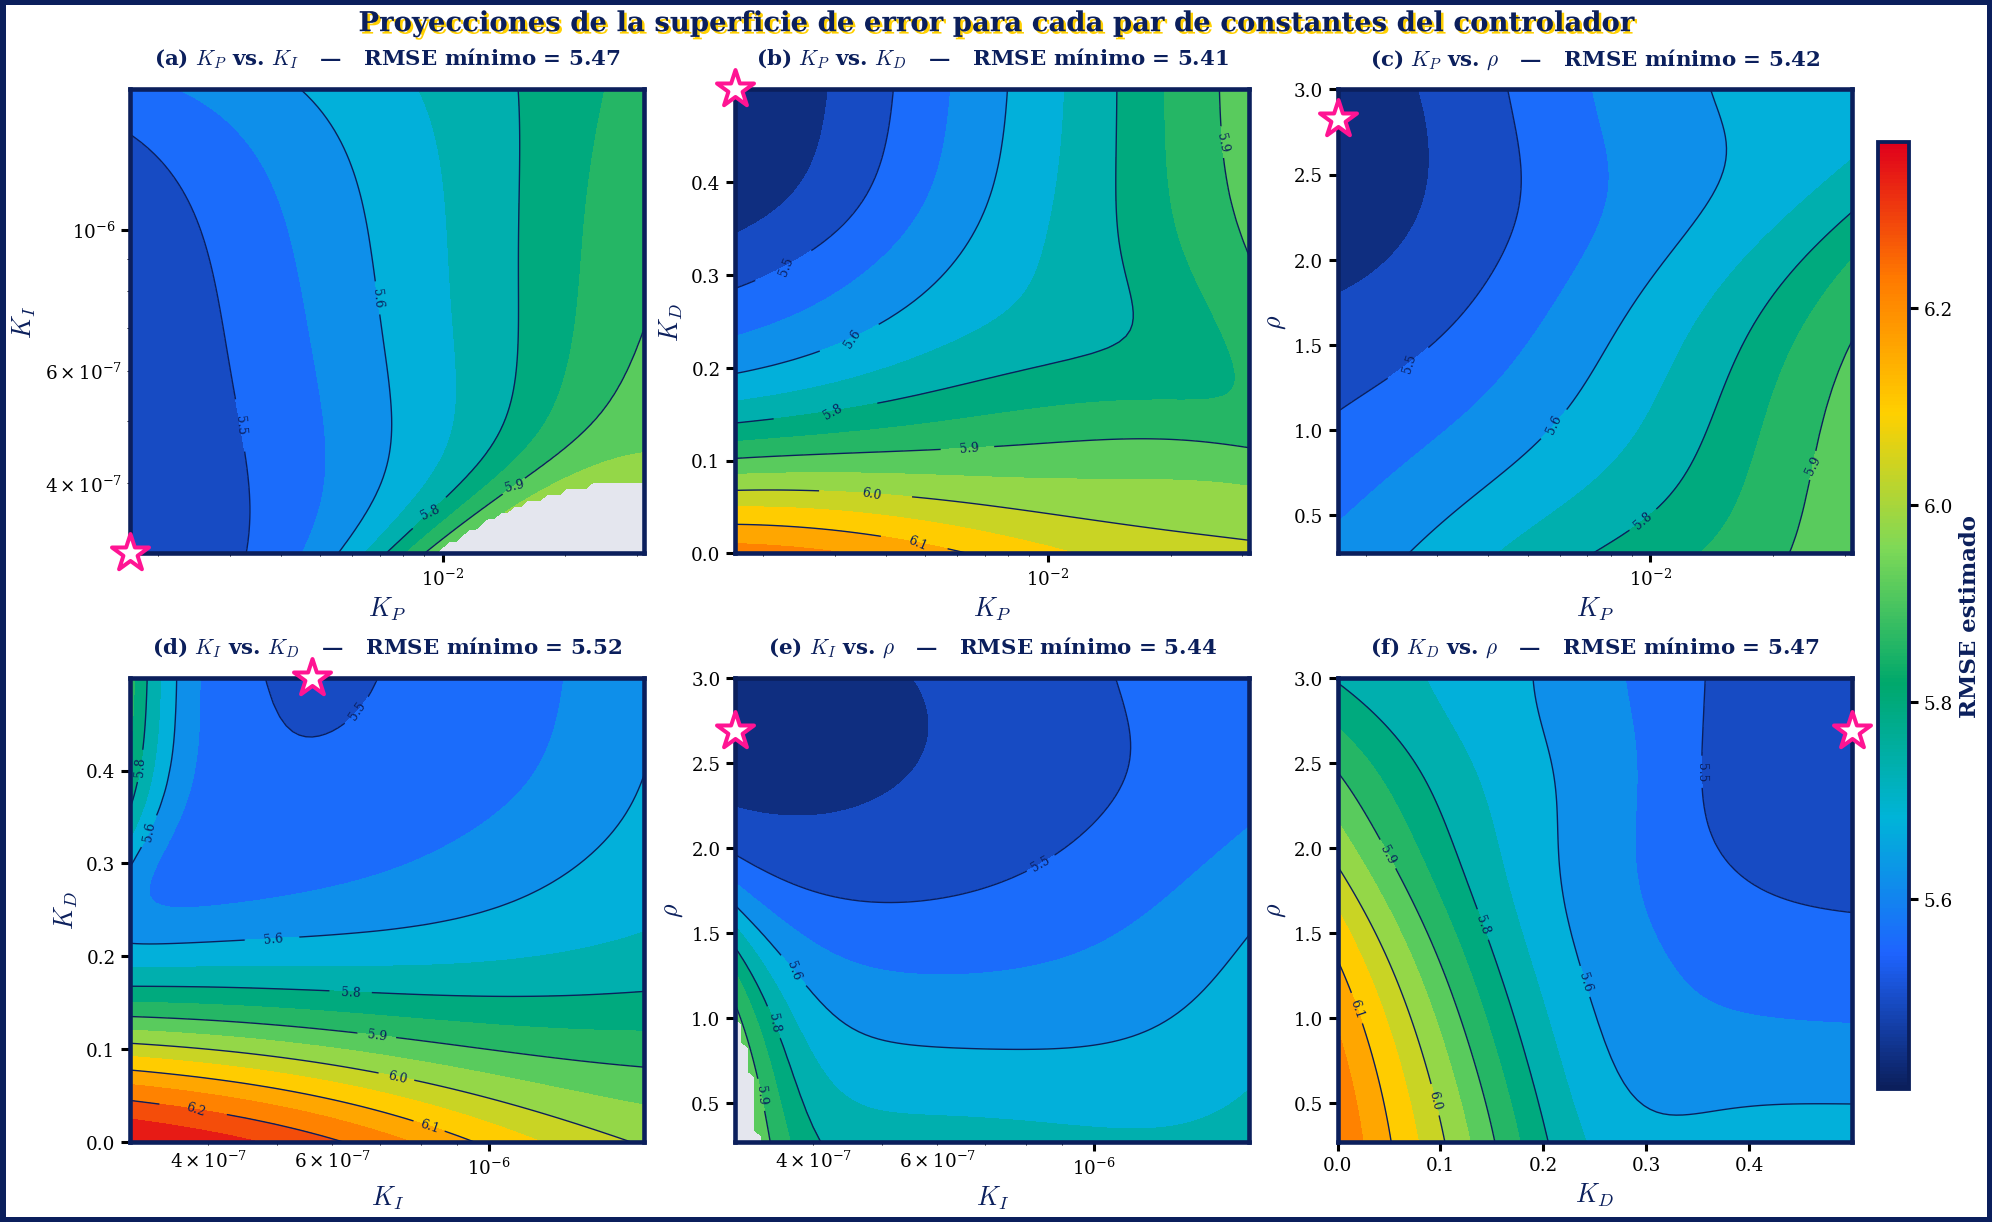

In [7]:
# Se define una escala de color común a los seis paneles, a partir de los extremos del RMSE
# estimado en todas las proyecciones.
vmin_pares = min(np.nanmin(p[2]) for p in proyecciones.values())
vmax_pares = max(np.nanmax(p[2]) for p in proyecciones.values())
norma_pares = Normalize(vmin=vmin_pares, vmax=vmax_pares)
niveles = np.linspace(vmin_pares, vmax_pares, 17)

fig3, ejes3 = plt.subplots(2, 3, figsize=(18, 11), constrained_layout=True)
letras = "abcdef"

for ax3, letra, (var_x, var_y) in zip(ejes3.ravel(), letras, pares_controlador):
    X, Y, E, x_min, y_min, e_min = proyecciones[(var_x, var_y)]

    # Se asigna un fondo gris claro, visible únicamente en las zonas de escaso soporte.
    ax3.set_facecolor("#E4E6EE")

    # Se dibujan los contornos rellenos del RMSE estimado y sus isolíneas.
    ax3.contourf(X, Y, E, levels=niveles, cmap=MAPA_RMSE, norm=norma_pares)
    isolineas3 = ax3.contour(X, Y, E, levels=niveles[::2], colors=AZUL_MARINO, linewidths=0.9)
    ax3.clabel(isolineas3, fmt="%.1f", fontsize=8, inline=True)

    # Se aplica la escala logarítmica a los ejes que corresponden a K_I.
    if VARIABLES[var_x]["logaritmica"]:
        ax3.set_xscale("log")
    if VARIABLES[var_y]["logaritmica"]:
        ax3.set_yscale("log")

    # Se señala el mínimo de la proyección mediante una estrella blanca con delineado rosa.
    ax3.scatter(x_min, y_min, marker="*", s=650, color=BLANCO, edgecolors=ROSA_FLUOR,
                linewidths=2.6, zorder=6, clip_on=False)

    # Se configuran las etiquetas, el título del panel y el grosor de los marcos.
    ax3.set_xlabel(VARIABLES[var_x]["etiqueta"], color=AZUL_MARINO, fontsize=17)
    ax3.set_ylabel(VARIABLES[var_y]["etiqueta"], color=AZUL_MARINO, fontsize=17)
    ax3.set_title(f"({letra}) {VARIABLES[var_x]['etiqueta']} vs. {VARIABLES[var_y]['etiqueta']}"
                  f"   —   RMSE mínimo = {e_min:.2f}",
                  color=AZUL_MARINO, fontweight="bold", fontsize=14, pad=16)
    for borde in ax3.spines.values():
        borde.set_linewidth(3.0)
        borde.set_edgecolor(AZUL_MARINO)

# Se agrega la barra de color común a los seis paneles.
barra3 = fig3.colorbar(ScalarMappable(norm=norma_pares, cmap=MAPA_RMSE), ax=ejes3.ravel().tolist(),
                       shrink=0.9, aspect=30, pad=0.015)
barra3.set_label("RMSE estimado", fontsize=15, color=AZUL_MARINO, fontweight="bold")
barra3.outline.set_linewidth(2.5)
barra3.outline.set_edgecolor(AZUL_MARINO)

fig3.suptitle("Proyecciones de la superficie de error para cada par de constantes del controlador",
              fontsize=18, color=AZUL_MARINO, fontweight="bold",
              path_effects=[pe.withSimplePatchShadow(offset=(1.6, -1.6), shadow_rgbFace=AMARILLO, alpha=1.0)])
fig3.patch.set_edgecolor(AZUL_MARINO)
fig3.patch.set_linewidth(6)

plt.show()

## 7. Exportación de las figuras

Las figuras se exportan en formato PDF (vectorial) y PNG a 300 ppp.

In [8]:
# Se crea la carpeta de salida
carpeta_salida = Path("figuras")
carpeta_salida.mkdir(exist_ok=True)

for figura, nombre in ((figura_3d, "superficie_KP_KD_rho_3D"), (fig2, "superficie_mapas_2D"),
                       (fig3, "superficie_proyecciones_pares")):
    for extension in ("pdf", "png"):
        figura.savefig(carpeta_salida / f"{nombre}.{extension}", bbox_inches="tight",
                       edgecolor=figura.get_edgecolor())

print("Figuras guardadas en:", carpeta_salida.resolve())

Figuras guardadas en: /tmp/claude-0/-home-claude/4a53ad9b-a2c3-5cde-9c7f-42b55f065395/scratchpad/ejec/figuras
